In [ ]:
%run scripts/verify_environment.py

verify_environment()

In [ ]:
from getpass import getpass

admin_rdm_url = 'https://admin.bh.rdm.yzwlab.com/' # 'https://admin.staging.rdm.example.com'
rdm_url = 'https://bh.rdm.yzwlab.com/' # 'https://staging.rdm.example.com'
institution_name_project_limit_1 = None
idp_name_project_limit_1 = None
idp_username_project_limit_1 = None
idp_password_project_limit_1 = None
idp_name_project_limit_2 = None
idp_username_project_limit_2 = None
idp_password_project_limit_2 = None

# 統合管理者用 (manager)
idp_name_integrated_admin = None
idp_username_integrated_admin = None
idp_password_integrated_admin = None

default_result_path = None
close_on_fail = False
transition_timeout = 30000

In [3]:
if institution_name_project_limit_1 is None:
    institution_name_project_limit_1 = input(prompt=f'Institution Name: ')

if idp_name_project_limit_1 is None:
    idp_name_project_limit_1 = input(prompt=f'IdP Name: ')
if idp_username_project_limit_1 is None:
    idp_username_project_limit_1 = input(prompt=f'Username for {idp_name_project_limit_1}')
if idp_password_project_limit_1 is None:
    idp_password_project_limit_1 = getpass(prompt=f'Password for {idp_username_project_limit_1}@{idp_name_project_limit_1}')
    
if idp_name_project_limit_2 is None:
    idp_name_project_limit_2 = input(prompt=f'IdP Name: ')
if idp_username_project_limit_2 is None:
    idp_username_project_limit_2 = input(prompt=f'Username for {idp_name_project_limit_2}')
if idp_password_project_limit_2 is None:
    idp_password_project_limit_2 = getpass(prompt=f'Password for {idp_username_project_limit_2}@{idp_name_project_limit_2}')

if idp_name_integrated_admin is None:
    idp_name_integrated_admin = input(prompt=f'IdP Name for integrated admin: ')
if idp_username_integrated_admin is None:
    idp_username_integrated_admin = input(prompt=f'Username for {idp_name_integrated_admin} (integrated admin)')
if idp_password_integrated_admin is None:
    idp_password_integrated_admin = getpass(prompt=f'Password for {idp_username_integrated_admin}@{idp_name_integrated_admin}')

In [4]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/tmp/tmp3trcjqtw'

# プロジェクト制限数_クリーンアップ処理

- サブシステム名: プロジェクト制限数
- ページ/アドオン: *
- 機能分類: *
- シナリオ名: プロジェクト制限数のクリーンアップ処理 (プロジェクト、設定、テンプレート)
- 用意するテストデータ: URL一覧、アカウント(既存ユーザー1: GRDM、 既存ユーザー2: GRDM、統合管理者既存ユーザー: GRDM)

In [5]:
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20260610-065312', '/tmp/tmpbdi9a4m2')

## ウェブブラウザの新規プライベートウィンドウでGRDMトップページを表示する

GRDMトップページが表示されること

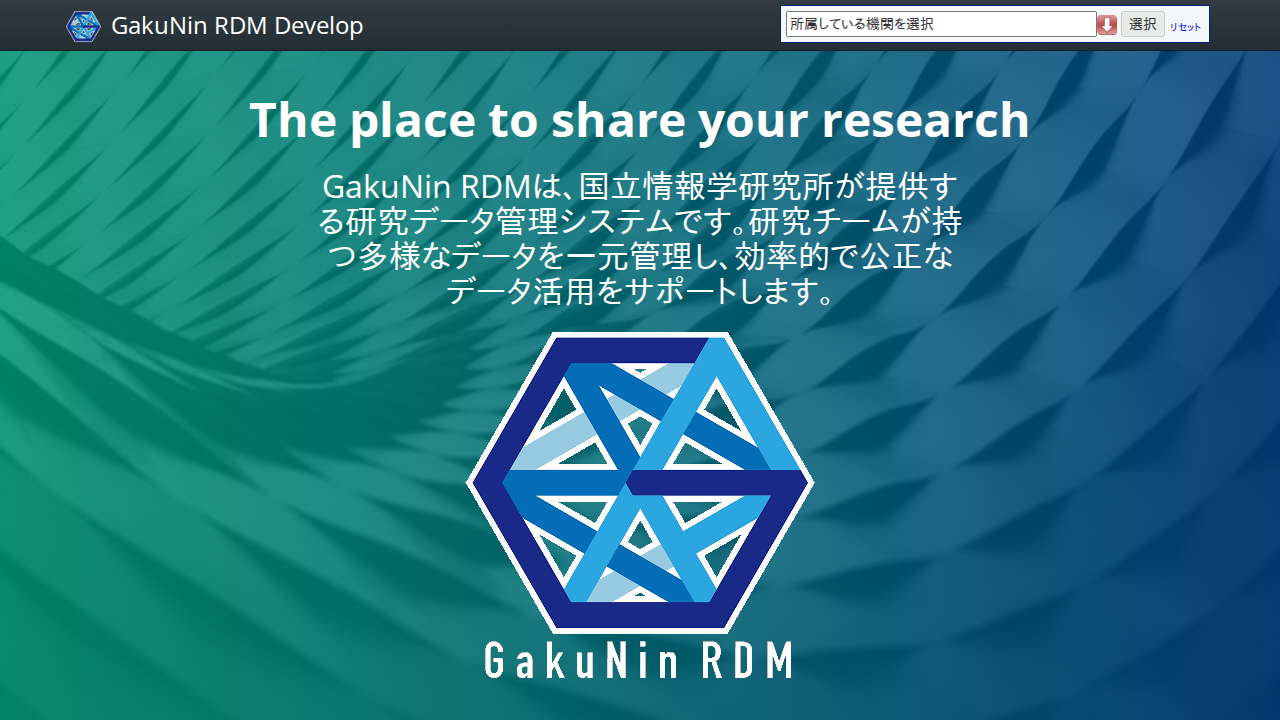

In [6]:
async def _step(page):
    await page.goto(rdm_url)

    # 同意する ボタンが現れるまで待つ
    await expect(page.locator('//button[text() = "同意する"]')).to_be_visible(timeout=transition_timeout)

    # 同意する をクリック
    await page.locator('//button[text() = "同意する"]').click()

    # 同意する が表示されなくなったことを確認
    await expect(page.locator('//button[text() = "同意する"]')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)

## RDMIdPを利用し、既存ユーザー1としてログインする

GRDMダッシュボードが表示されること

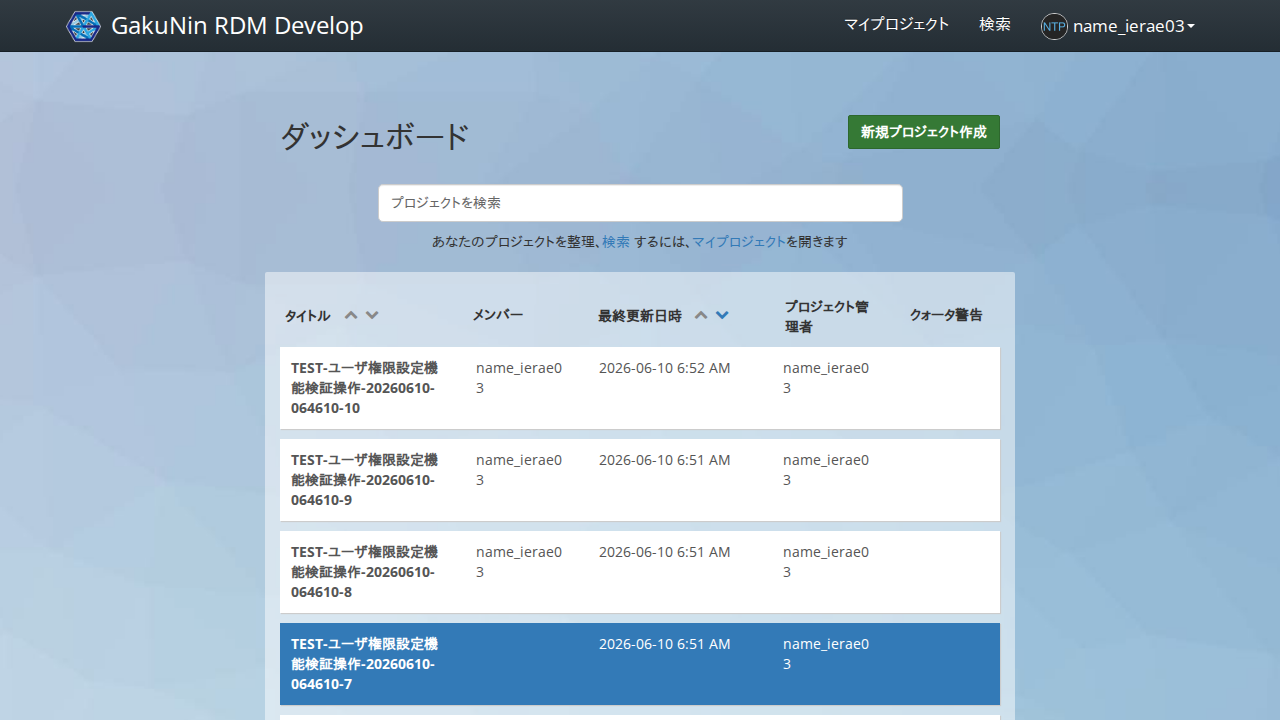

In [7]:
async def _step(page):
    await scripts.grdm.login(
        page, idp_name_project_limit_1, idp_username_project_limit_1, idp_password_project_limit_1, transition_timeout=transition_timeout
    )

    await scripts.grdm.expect_dashboard(page, transition_timeout=transition_timeout)

await run_pw(_step)

## すべてのプロジェクトを削除する

・すべてのプロジェクトが消えること

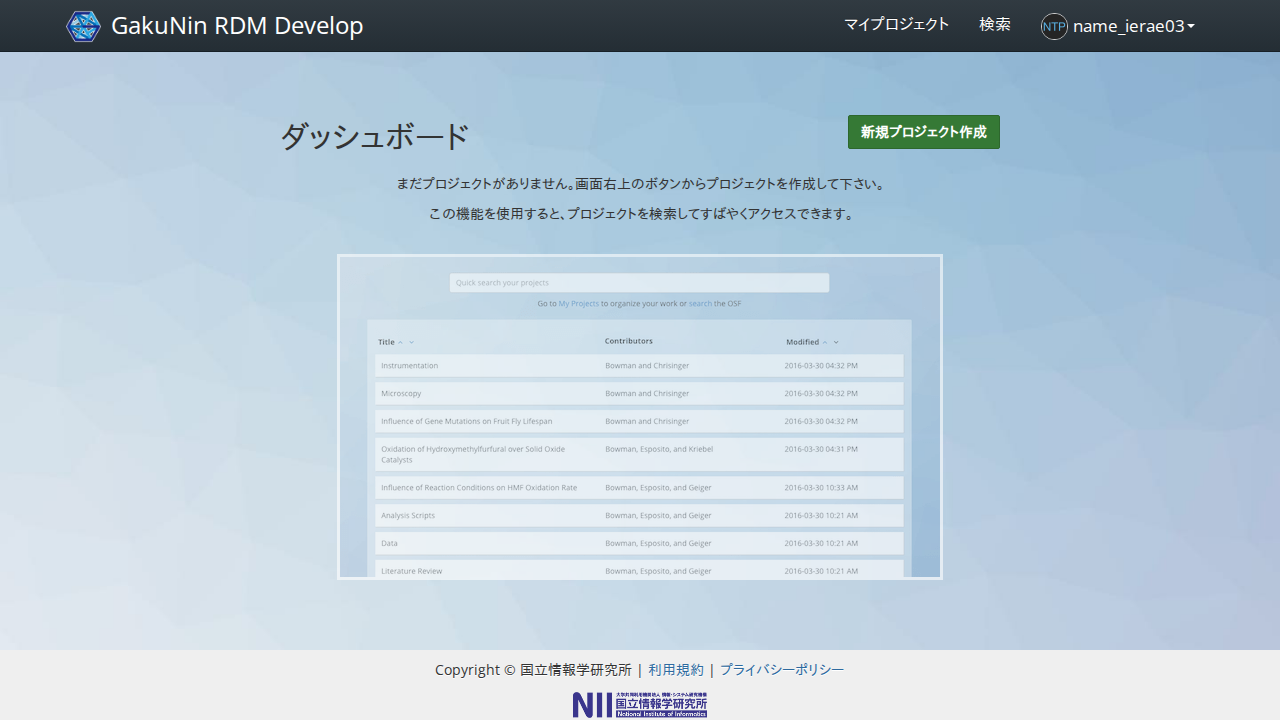

In [8]:
async def _step(page):
    while await page.locator('//*[@data-test-dashboard-item-title]').count() > 0:
        await page.locator('//*[@data-test-dashboard-item-title]').first.click()
        await scripts.grdm.delete_project(page)
        await scripts.grdm.expect_dashboard(page, transition_timeout=transition_timeout)

    await expect(page.locator('//*[@data-test-dashboard-item-title]')).to_have_count(0)

await run_pw(_step)

## 既存ユーザー1をログアウトする

ログアウトが完了すること

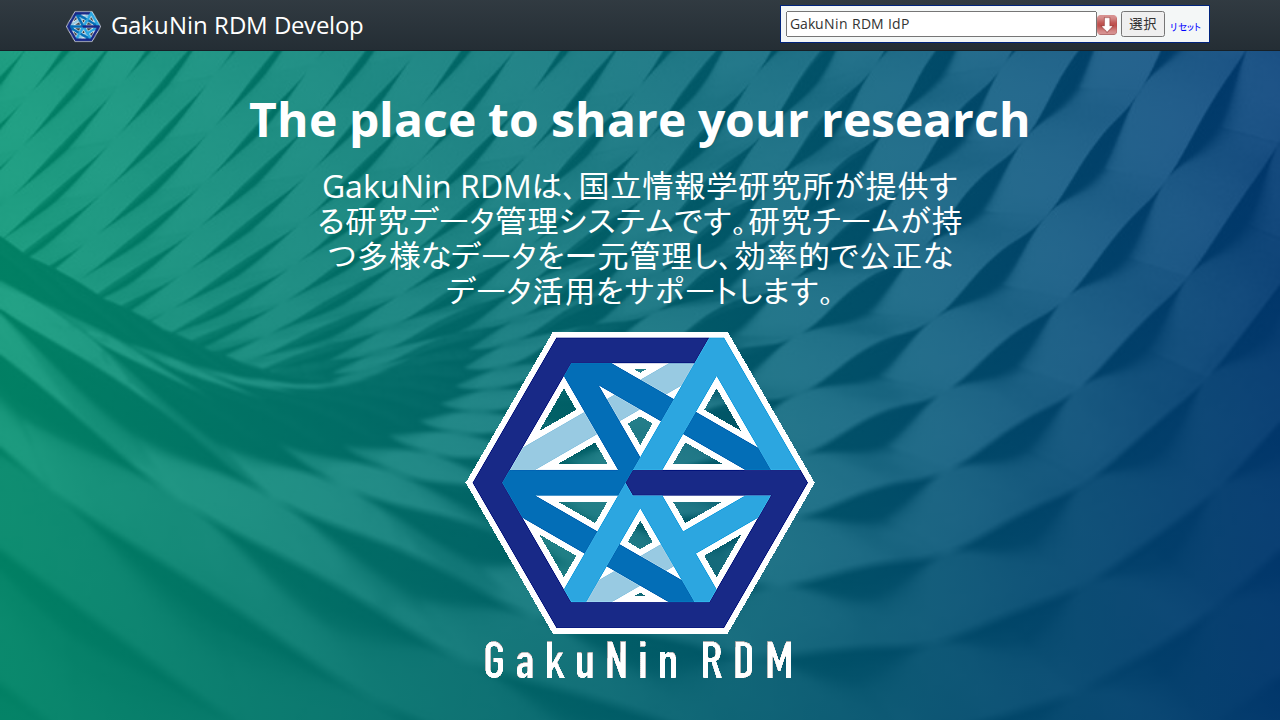

In [9]:
async def _step(page):
    await grdm.logout(page, idp_name_project_limit_1, transition_timeout=transition_timeout)

await run_pw(_step)

## RDMIdPを利用し、既存ユーザー2としてログインする

・GRDMダッシュボードが表示されること   

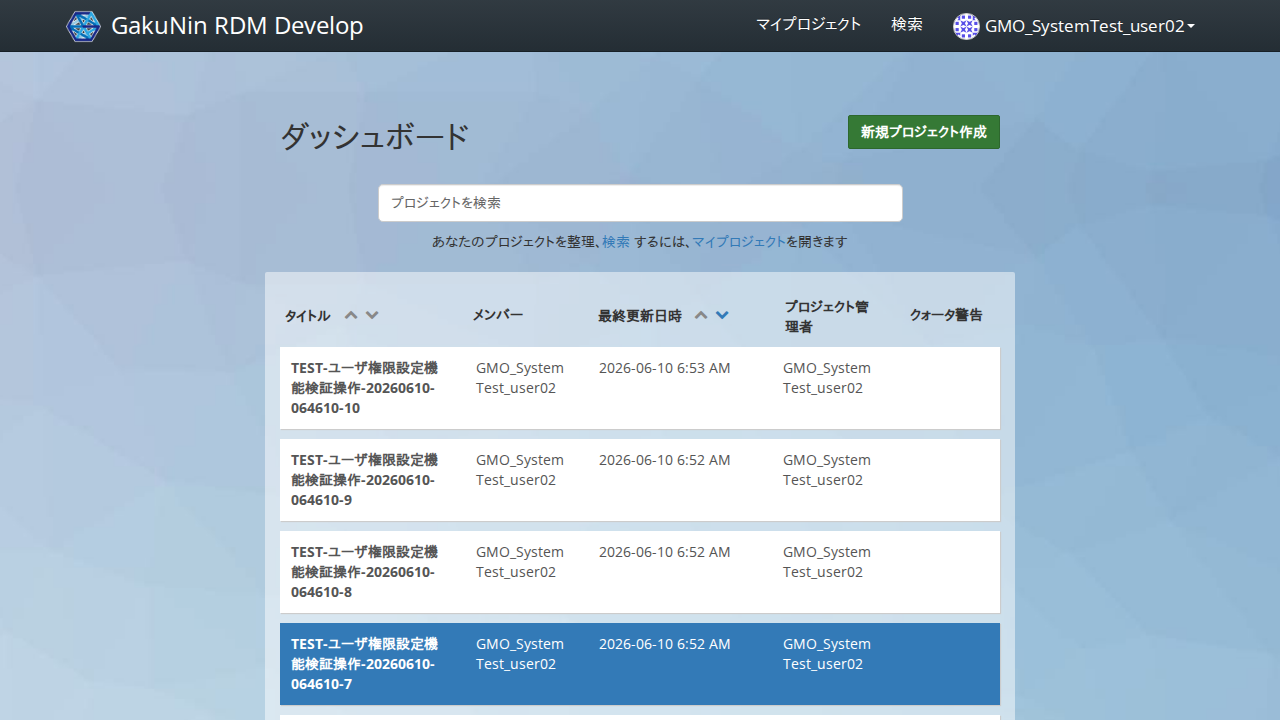

In [ ]:
async def _step(page):
    if idp_name_project_limit_2 != 'FakeCAS':
        # ログアウト後、トップページは機関が選択済みの状態で表示される。
        # ログインを実施できるようにするため、トップページを未選択状態へ戻す目的でリセットボタンおよび dropdown_up ボタンをクリックする。
        await page.locator('//*[@id = "clear_a"]').click()
        await page.locator('//*[@id = "dropdown_img"]').click()
        await expect(page.locator('img[src*="dropdown_down.png"]')).to_be_visible(timeout=transition_timeout)

    await scripts.grdm.login(
        page, idp_name_project_limit_2, idp_username_project_limit_2, idp_password_project_limit_2, transition_timeout=transition_timeout
    )

    await scripts.grdm.expect_dashboard(page, transition_timeout=transition_timeout)

await run_pw(_step)

## すべてのプロジェクトを削除する

・すべてのプロジェクトが消えること

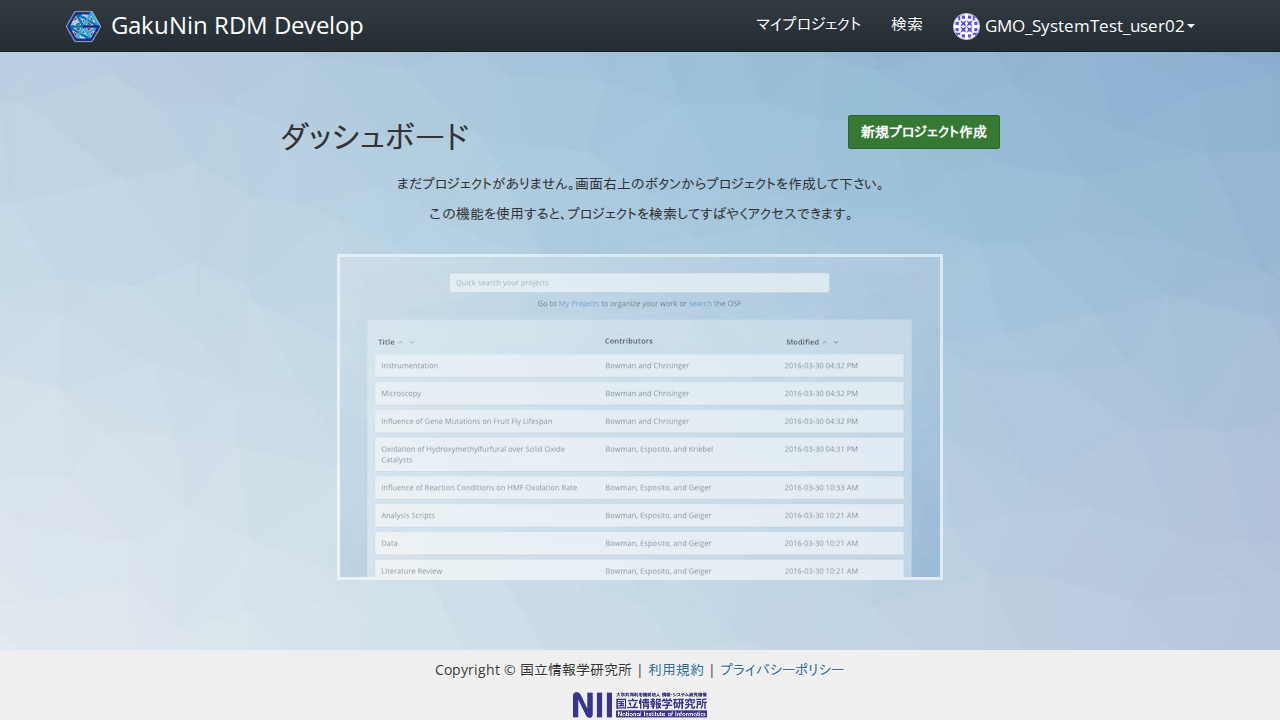

In [11]:
async def _step(page):
    while await page.locator('//*[@data-test-dashboard-item-title]').count() > 0:
        await page.locator('//*[@data-test-dashboard-item-title]').first.click()
        await scripts.grdm.delete_project(page)
        await scripts.grdm.expect_dashboard(page, transition_timeout=transition_timeout)

    await expect(page.locator('//*[@data-test-dashboard-item-title]')).to_have_count(0)

await run_pw(_step)

## ウェブブラウザの新規プライベートウィンドウで GRDM 管理者トップページを表示する

GRDM 管理者トップページが表示されること

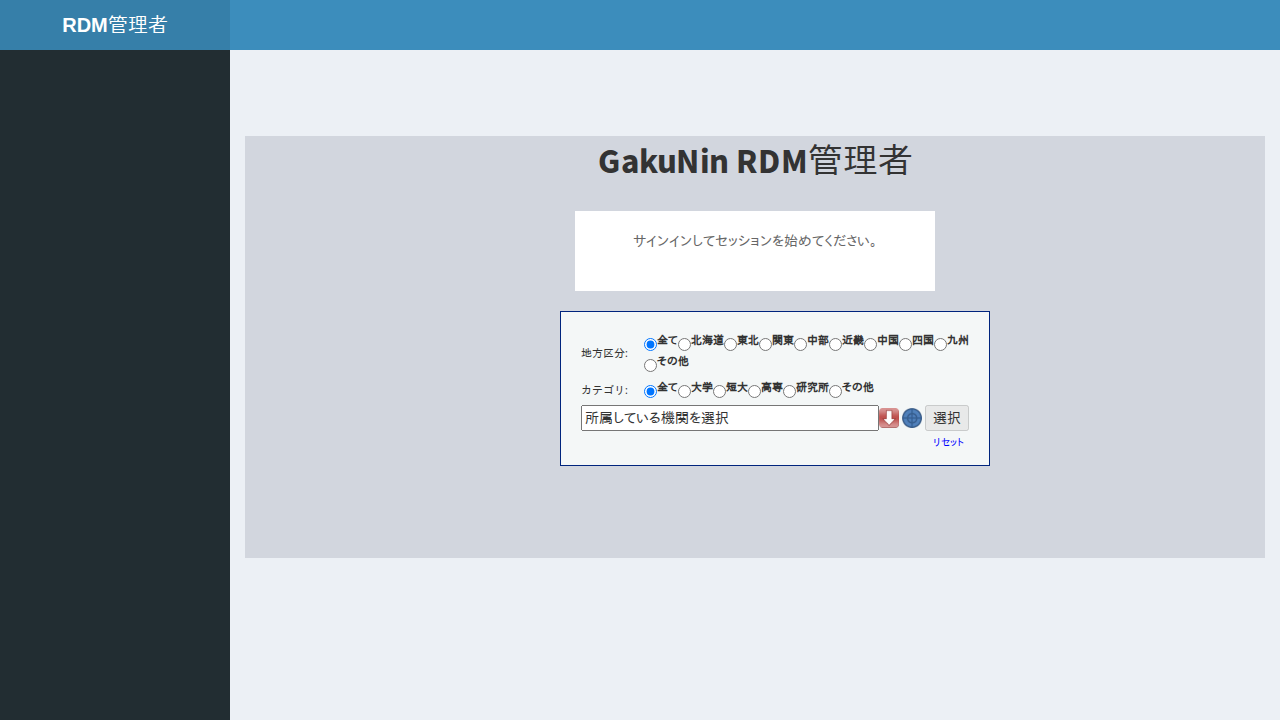

In [12]:
async def _step(page):
    await page.goto(admin_rdm_url)

    await expect(page.locator('.login-logo')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## アカウント(統合管理者既存ユーザー)を用いてGakuNin RDMにログインする

(IdPに関するログイン情報が与えられた場合、)
GakuNin Embeded DSのプルダウンを展開し、IdPリストから指定されたIdPを選択する。その後、アカウントのID/Passwordを入力して「Login」ボタンを押下する。

(IdPが指定されていない場合、)
CASのログイン操作を実施する。

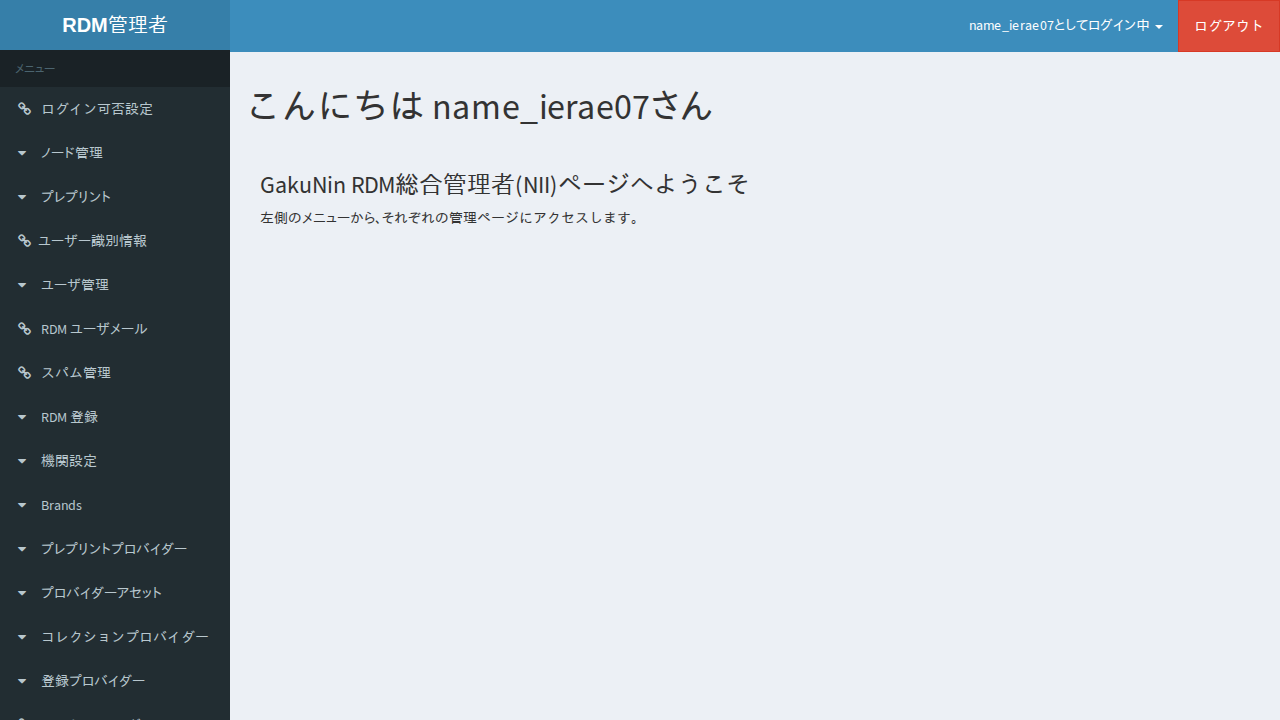

In [13]:
async def _step(page):
    await scripts.grdm.login_as_admin(
        page, idp_name_integrated_admin, idp_username_integrated_admin, idp_password_integrated_admin, transition_timeout=transition_timeout
    )

    await expect(page.locator('//*[contains(@class, "btn-danger") and contains(text(), "ログアウト")]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## メニューから「プロジェクト制限数」をクリックする

「設定テンプレート」「設定」のサブメニューが表示されること

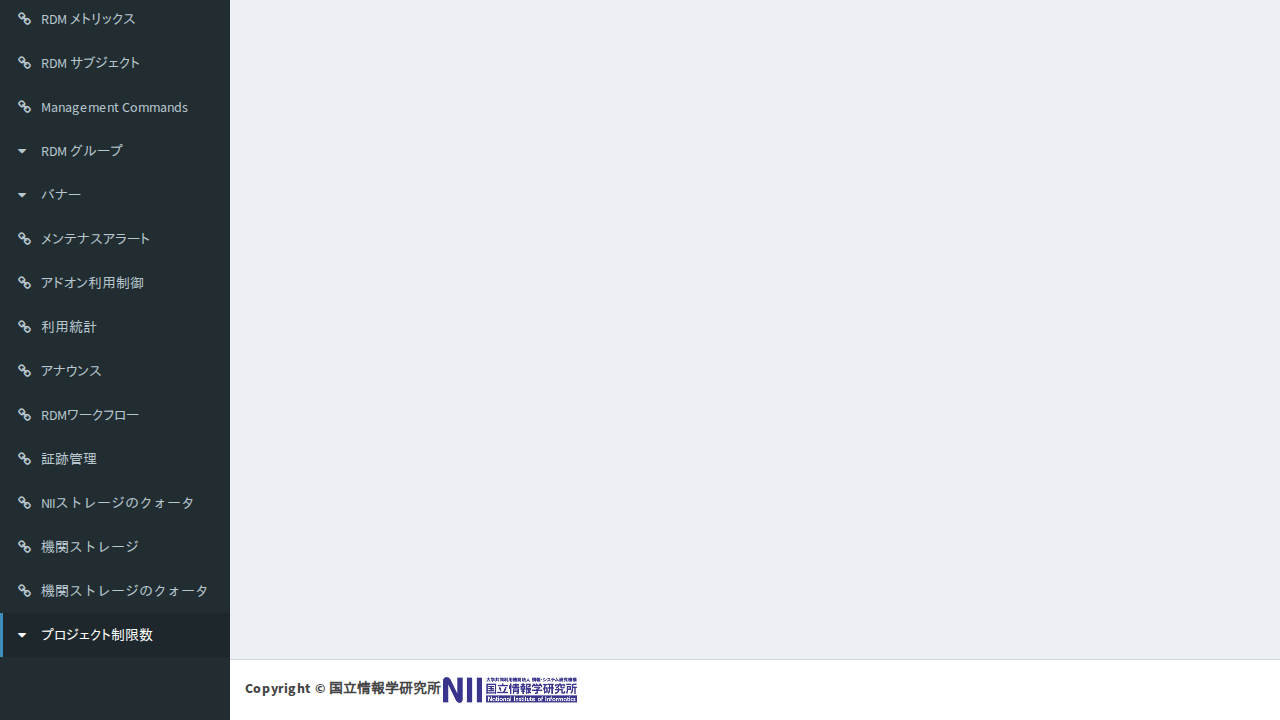

In [14]:
async def _step(page):
    await page.locator('//a[@href = "#collapseProjectLimitNumber"]').click()

    await expect(page.locator('//a[@href = "/project_limit_number/templates/"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//a[@href = "/project_limit_number/settings/"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## サブメニューから「設定」をクリックする

「プロジェクト作成数設定一覧」画面が表示されること

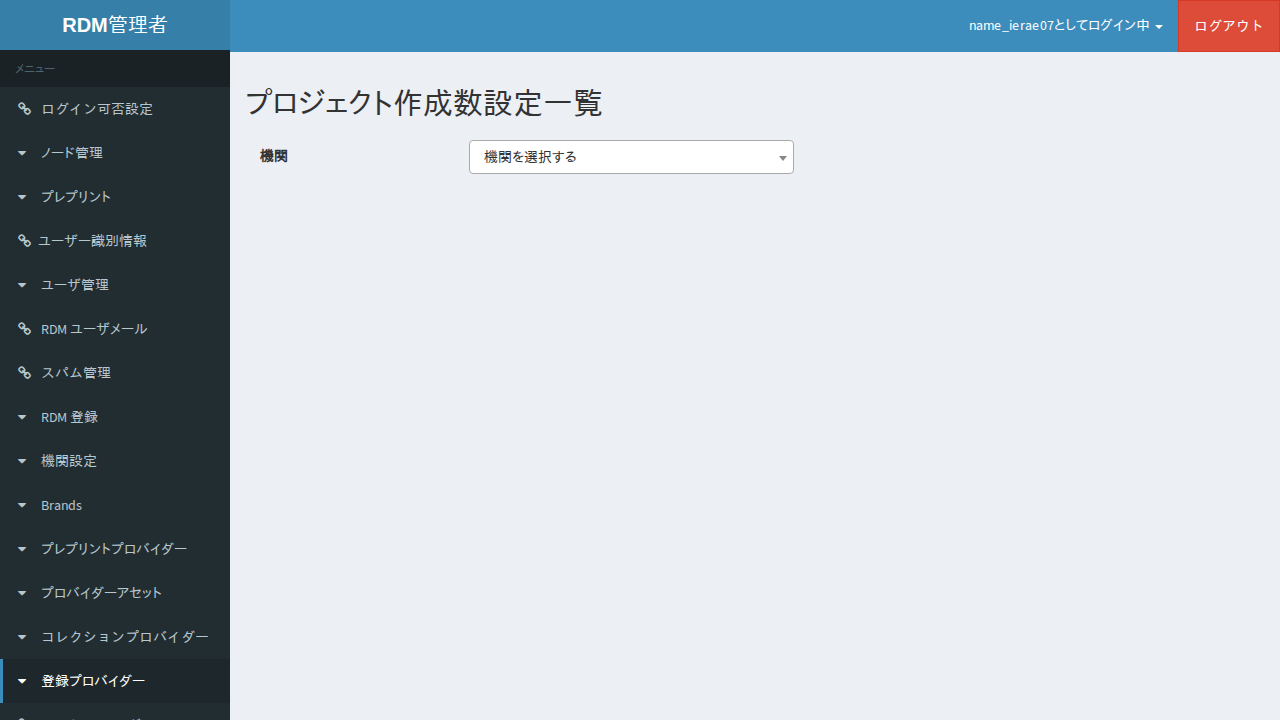

In [15]:
async def _step(page):
    await page.locator('//a[@href = "/project_limit_number/settings/"]').click()

    await expect(page.locator('//h2[text() = "プロジェクト作成数設定一覧"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「機関」の「機関を選択する」をクリックし、「テンプレート作成・変更・削除」シートのNo. 2 のユーザが所属する機関を選択する

「プロジェクト制限のデフォルト」以下の項目が表示されること

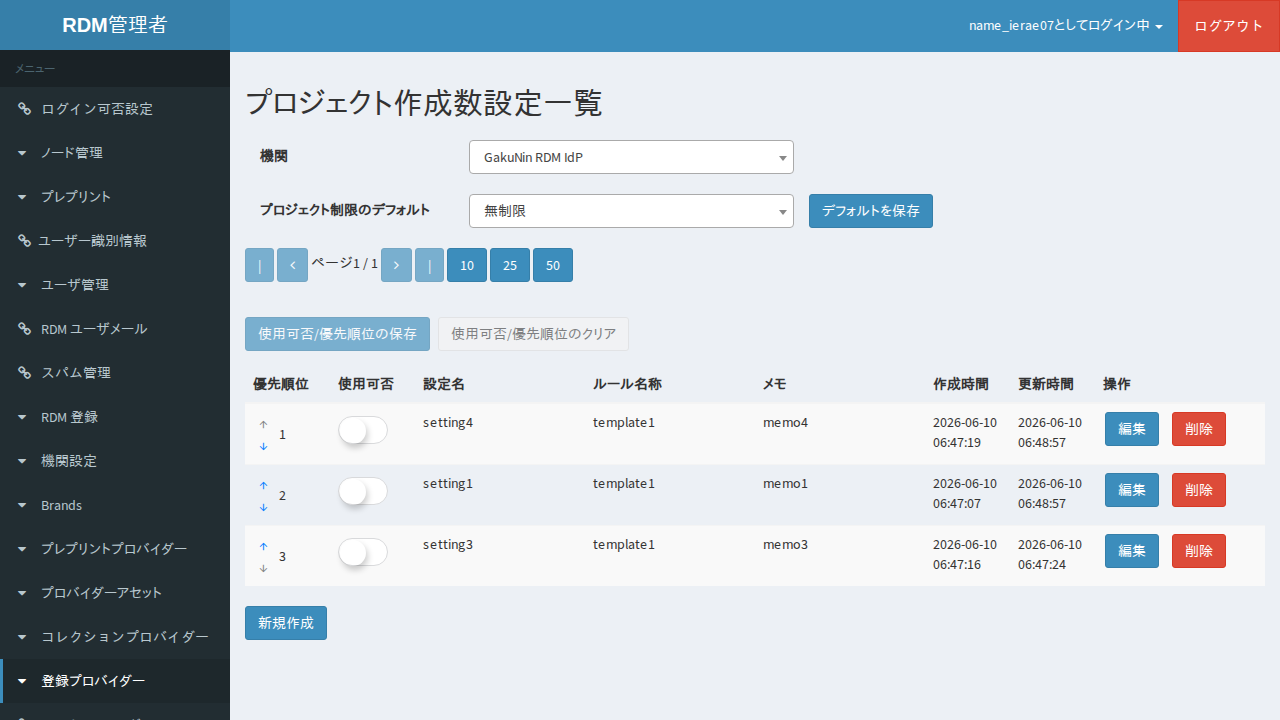

In [16]:
async def _step(page):
    await page.locator('#institution_id').select_option(label=f'{institution_name_project_limit_1}')
    
    # 「プロジェクト制限のデフォルト」以下の項目が表示されることを確認
    await expect(page.locator('#project_limit_number_default_id')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('button', has_text='デフォルトを保存')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#save_changes_button')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#clear_changes_button')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#setting-table')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('a', has_text='新規作成')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「プロジェクト作成数設定一覧」画面に存在するすべての設定を削除する

・すべての設定が消えること

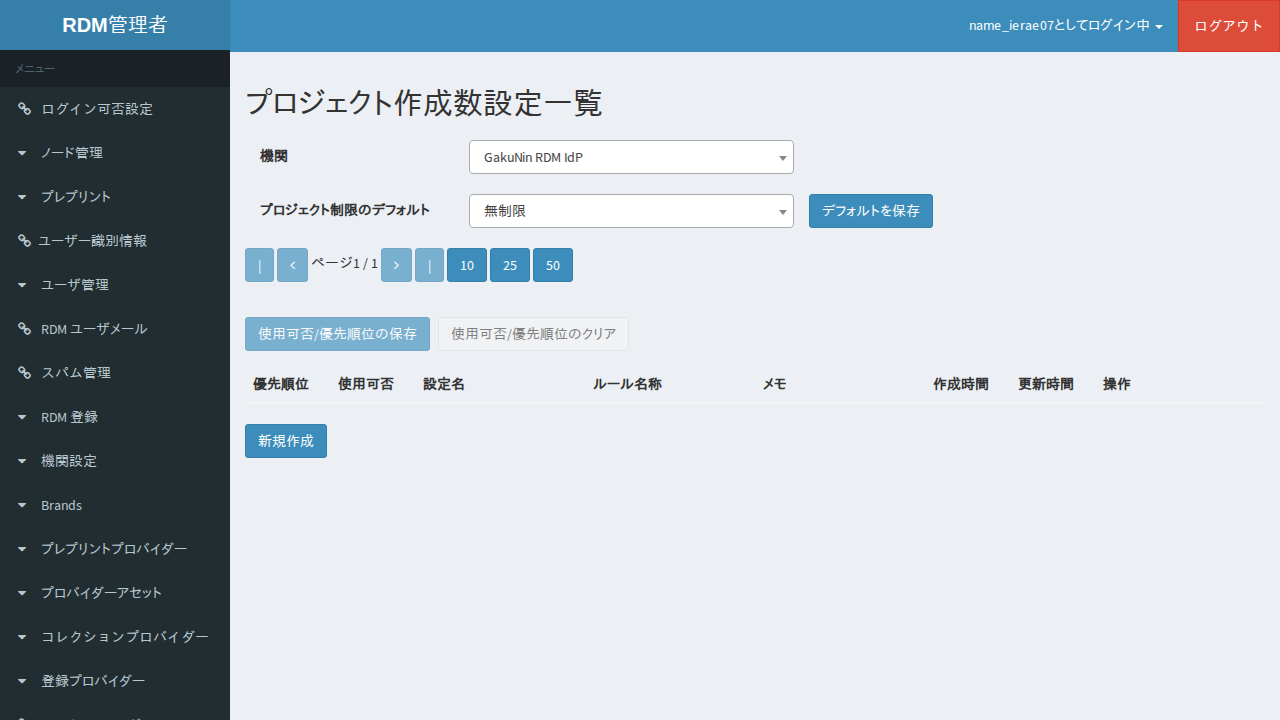

In [17]:
async def _step(page):
    while await page.locator('#setting-table tbody tr').count() > 0:
        row = page.locator('#setting-table tbody tr').first
        await row.locator('button:has-text("削除")').click()

        modal = page.locator('#deleteSetting')
        await expect(modal).to_contain_text('この設定を削除してもよろしいですか?', timeout=transition_timeout)
        await page.locator('#submitDeleteButton').click()
        await expect(modal).to_be_hidden(timeout=transition_timeout)

    await expect(page.locator('#setting-table tbody tr')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)

## メニューから「プロジェクト制限数」をクリックする

「設定テンプレート」「設定」のサブメニューが表示されること

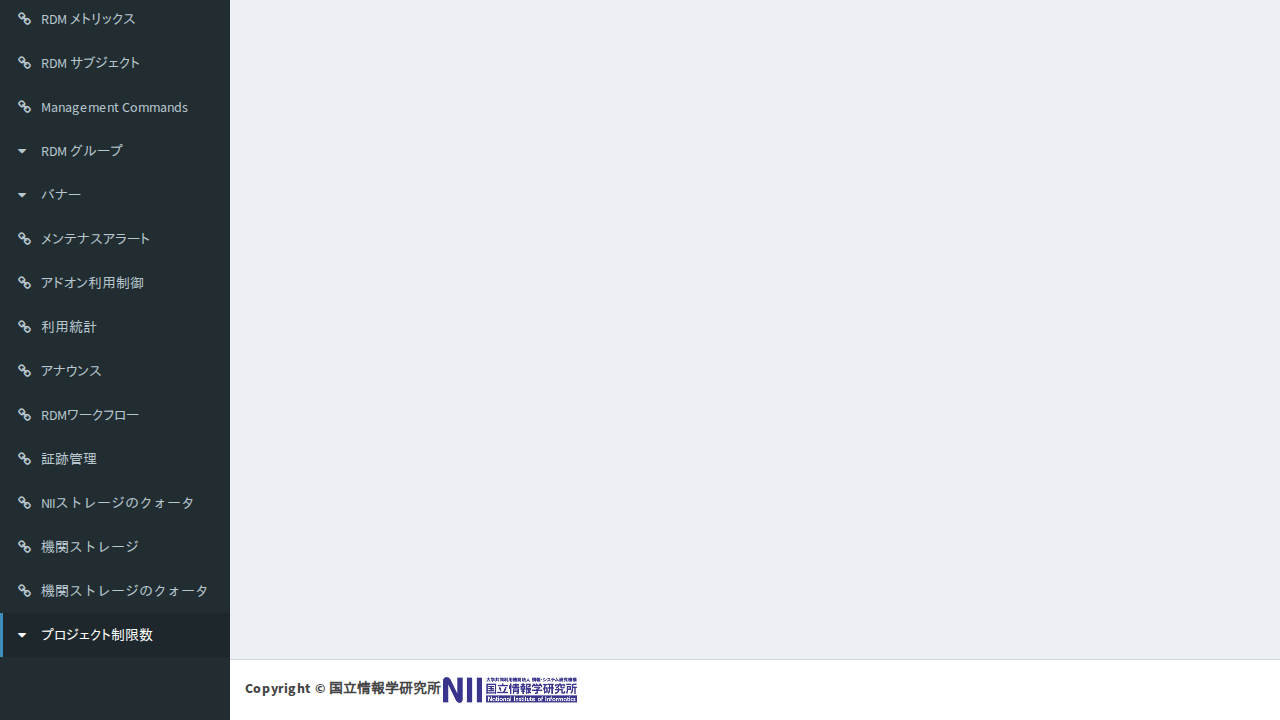

In [18]:
async def _step(page):
    await page.locator('//a[@href = "#collapseProjectLimitNumber"]').click()

    await expect(page.locator('//a[@href = "/project_limit_number/templates/"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//a[@href = "/project_limit_number/settings/"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## サブメニューから「設定テンプレート」をクリックする

・「プロジェクト作成数設定テンプレート一覧」画面が表示されること  

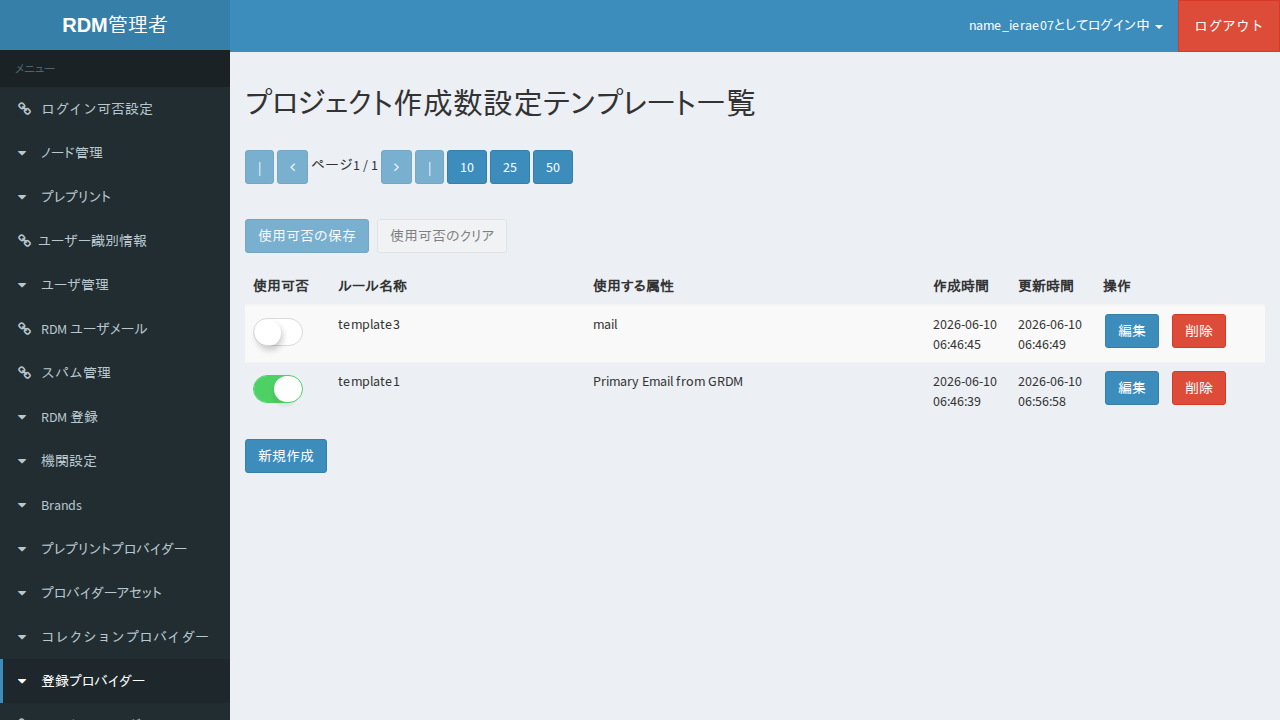

In [19]:
async def _step(page):
    await page.locator('//a[@href = "/project_limit_number/templates/"]').click()

    await expect(page.locator('//h2[text() = "プロジェクト作成数設定テンプレート一覧"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「プロジェクト作成数設定テンプレート一覧」画面に存在するすべてのテンプレートを削除する

・すべてのテンプレートが消えること

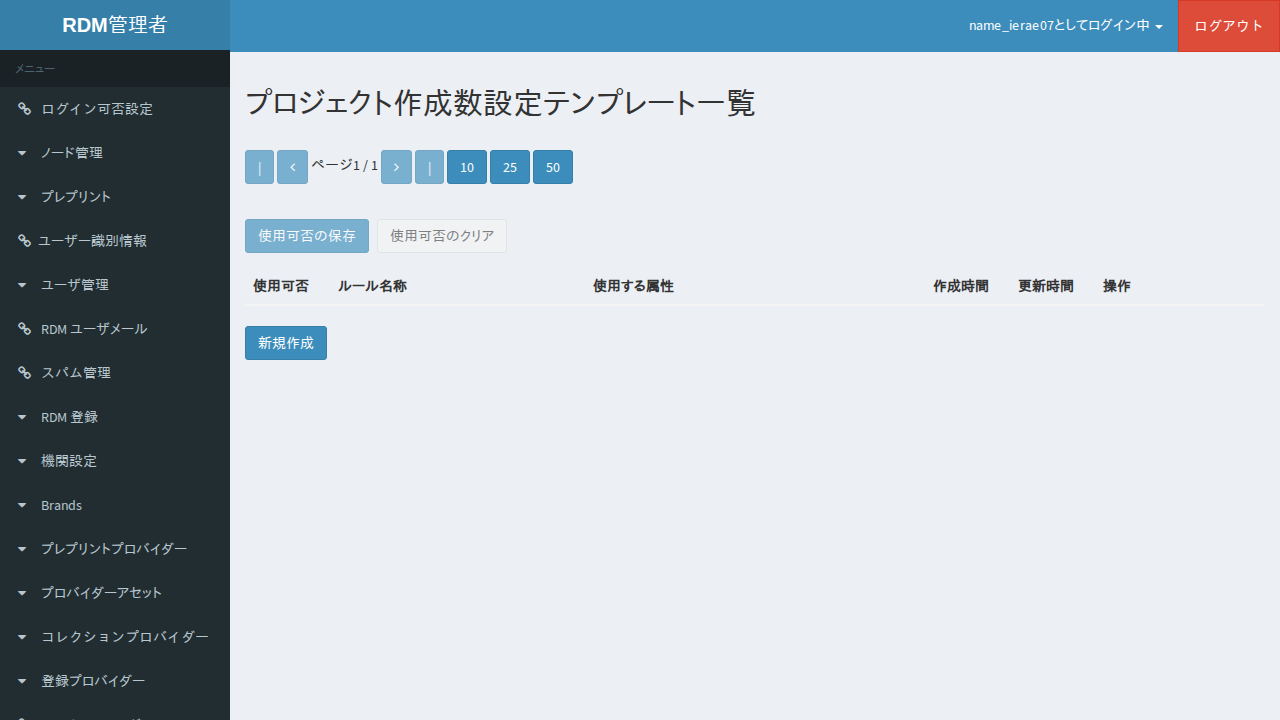

In [20]:
async def _step(page):
    while await page.locator('#setting-template-table tbody tr').count() > 0:
        row = page.locator('#setting-template-table tbody tr').first
        await row.locator('button[id^="delete_template_setting_"]').click()
        
        modal = page.locator('#deleteSettingTemplate')
        await expect(modal).to_contain_text('このテンプレートを削除してもよろしいですか?', timeout=transition_timeout)
        await page.locator('#submitDeleteButton').click()
        await expect(modal).to_be_hidden(timeout=transition_timeout)

    await expect(page.locator('#setting-template-table tbody tr')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)

終了処理を実施。

In [21]:
await finish_pw_context()

In [22]:
!rm -fr {work_dir}